In [4]:
import os
import glob
import json
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# ---- 1. RÉGLAGES GLOBAUX ----
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# ---- 2. CONFIGURATION DUCKDB ----
con = duckdb.connect()
con.execute("PRAGMA memory_limit='200GB'")
con.execute("PRAGMA threads=64") 

# ---- 3. CHARGEMENT DU MAPPING DES SOURCES ----
SOURCE_MAP_PATH = "/data/gdelt/gdelt_sources_mapping.json"
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "Src_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

# ---- 4. CRÉATION DIRECTE DE LA VUE GKG_FINAL ----
print("⏳ Création de la vue 'gkg_final' unique et optimisée...")

query_final = """
    CREATE OR REPLACE VIEW gkg_final AS
    
    WITH raw_prefiltered AS (
        -- 1. Filtres allégés
        SELECT *
        FROM read_parquet('/data/gdelt/gdelt_parquet_db/gdelt_*.parquet')
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
          AND EnhancedThemes IS NOT NULL 
          AND EnhancedThemes != ''
          AND WordCount BETWEEN 15 AND 6500
          AND ARRAY_LENGTH(string_split(EnhancedThemes, ';')) >= 2
    ),
    repaired_sources AS (
        -- 2. On exclut le VIEUX nom (SourceCommonName_ID) de la base d'origine
        -- et on crée la NOUVELLE colonne (SourceCommonName_ID) réparée
        SELECT 
            r.* EXCLUDE (SourceCommonName_ID),
            COALESCE(NULLIF(r.SourceCommonName_ID, 0), m.Src_ID) AS Src_ID
        FROM raw_prefiltered r
        LEFT JOIN src_map m 
          ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
    )
    
    -- 3. Jointure avec ta whitelist qui utilise 'Src_ID'
    SELECT s.*
    FROM repaired_sources s
    INNER JOIN read_parquet('valid_sources_whitelist.parquet') w
      ON s.Src_ID = w.Src_ID;
"""

con.execute(query_final)
print("✅ Base initialisée ! La vue 'gkg_final' est prête.")

<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_676173/3785376693.py:37: SyntaxWarning: invalid escape sequence '\d'
  query_final = """


⏳ Création de la vue 'gkg_final' unique et optimisée...
✅ Base initialisée ! La vue 'gkg_final' est prête.


In [5]:
print("Schéma de la table nettoyée :")
display(con.execute("DESCRIBE gkg_final").df())
             
print("\n Aperçu des 5 premières lignes :")
display(con.execute("SELECT * FROM gkg_final LIMIT 5").df())

Schéma de la table nettoyée :


,column_name,column_type,null,key,default,extra
0,GKGRECORDID,VARCHAR,YES,None,None,None
1,DATE,VARCHAR,YES,None,None,None
2,SourceCollectionIdentifier,TINYINT,YES,None,None,None
3,DocumentIdentifier,VARCHAR,YES,None,None,None
4,EnhancedThemes,VARCHAR,YES,None,None,None
5,EnhancedLocations,VARCHAR,YES,None,None,None
6,Persons,VARCHAR,YES,None,None,None
7,Organizations,VARCHAR,YES,None,None,None
8,TranslationInfo,VARCHAR,YES,None,None,None
9,IsTranslingual,TINYINT,YES,None,None,None



 Aperçu des 5 premières lignes :


,GKGRECORDID,DATE,SourceCollectionIdentifier,DocumentIdentifier,EnhancedThemes,EnhancedLocations,Persons,Organizations,TranslationInfo,IsTranslingual,Tone,WordCount,Src_ID
0,20150228031500-1,20150228031500,1,http://ringsidereport.com/?p=51244,"TAX_WORLDMAMMALS_TIGER,238;TAX_WORLDMAMMALS_TI...",1#Nigeria#CU#NI##10#8#NI#61;1#Nigeria#CU#NI##1...,jose torres;rory calhoun;nino benvenuti;les mc...,,,0,-2.69,838,1787
1,20150228031500-2,20150228031500,1,http://www.mandurahmail.com.au/story/2913834/i...,"MEDIA_MSM,251;TAX_ETHNICITY_AUSTRALIANS,118;TA...",1#Australians#ID#AS##-27#133#AS#118;1#Indonesi...,joko widodo;myuran sukumaran;andrew chan,old parliament house,,0,-2.70,176,3015
2,20150228031500-3,20150228031500,1,http://www.voxy.co.nz/politics/trade-minister-...,"TAX_FNCACT_PRESIDENT,330;LEADER,318;TAX_FNCACT...",1#New Zealand#NZ#NZ##-41#174#NZ#646;1#New Zeal...,tim groser;gao hucheng,,,0,5.45,152,556
3,20150228031500-4,20150228031500,1,http://www.newindianexpress.com/cities/hyderab...,"TAX_WORLDLANGUAGES_KORRA,1449;TAX_WORLDLANGUAG...","4#Hyderabad, Andhra Pradesh, India#IN#IN02#175...",anurag chaturvedi;krishi vignan kendras,jayashankar telangana state agricultural unive...,,0,1.39,331,313
4,20150228031500-5,20150228031500,1,http://www.goal.com/en/news/9/england/2015/02/...,"TAX_ETHNICITY_COLOMBIAN,703;TAX_FNCACT_STRIKER...",1#Colombian#CO#CO##4#-72#CO#703;1#Dutchman#CO#...,van persie;david moyes;louis van gaal;radamel ...,united premier league;champions league,,0,-1.51,364,469


In [6]:
# Requête pour compter les articles et les sources uniques
df_totaux = con.execute("""
    SELECT 
        COUNT(*) AS total_articles,
        COUNT(DISTINCT Src_ID) AS total_sources
    FROM gkg_final;
""").df()

# Affichage formaté pour que ce soit bien lisible (avec les séparateurs de milliers)
nb_articles = df_totaux['total_articles'][0]
nb_sources = df_totaux['total_sources'][0]

print(f"Bilan de la base gkg_final :")
print(f"   - Nombre d'articles : {nb_articles:,.0f}".replace(',', ' '))
print(f"   - Nombre de sources : {nb_sources:,.0f}".replace(',', ' '))

Bilan de la base gkg_final :
   - Nombre d'articles : 1 427 608 918
   - Nombre de sources : 70 731


In [8]:
print("Tops on a uniform 1% sample (Hash Method)...")

top_themes_sample = con.execute("""
    SELECT split_part(TRIM(theme_raw), ',', 1) AS Theme, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
        FROM gkg_final
        WHERE hash(GKGRECORDID) % 100 = 0
          AND EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    )
    WHERE TRIM(theme_raw) != ''
    GROUP BY Theme 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()
                   
top_persons_sample = con.execute("""
    SELECT TRIM(person) AS Person, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(Persons, ';')) AS person
        FROM gkg_final
        WHERE hash(GKGRECORDID) % 100 = 0
          AND Persons IS NOT NULL AND Persons != ''
    )
    WHERE TRIM(person) != ''
    GROUP BY Person 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()
                         
top_orgs_sample = con.execute("""
    SELECT TRIM(org) AS Organization, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(Organizations, ';')) AS org
        FROM gkg_final
        WHERE hash(GKGRECORDID) % 100 = 0
          AND Organizations IS NOT NULL AND Organizations != ''
    )
    WHERE TRIM(org) != ''
    GROUP BY Organization 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()
                                                                     
top_locs_sample = con.execute("""
    SELECT split_part(TRIM(loc), '#', 2) AS Location, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(EnhancedLocations, ';')) AS loc
        FROM gkg_final
        WHERE hash(GKGRECORDID) % 100 = 0
          AND EnhancedLocations IS NOT NULL AND EnhancedLocations != ''
    )
    WHERE TRIM(loc) != '' AND split_part(TRIM(loc), '#', 2) != ''
    GROUP BY Location 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()
                                                            
top_sources_sample = con.execute("""
    SELECT 
        m.SourceCommonName AS Source_Name, 
        CAST(g.Src_ID AS VARCHAR) AS Source_ID, 
        COUNT(*) AS Articles
    FROM gkg_final g
    JOIN src_map m ON g.Src_ID = m.SourceCommonName_ID 
    GROUP BY m.SourceCommonName, g.Src_ID
    ORDER BY Articles DESC
    LIMIT 50
""").df()
                                                                                              
def display_side_by_side(dfs, titles):
                                                                                                    
    html_str = '<div style="display: flex; flex-wrap: wrap; gap: 30px; align-items: flex-start;">'
    
    for df, title in zip(dfs, titles):
                                                                                        
        styled_df = df.style.format(thousands=",")\
                            .hide(axis="index")\
                            .set_table_styles([
                                {'selector': 'td, th', 
                                 'props': [('max-width', '250px'), 
                                           ('white-space', 'normal'), 
                                           ('word-wrap', 'break-word')]}
                            ])
        
        html_str += f'<div style="flex: 0 0 auto; overflow-x: auto;">'
        html_str += f'<h3 style="text-align: center; margin-bottom: 10px;">{title}</h3>'
        html_str += styled_df.to_html()
        html_str += '</div>'
        
    html_str += '</div>'
    display(HTML(html_str))
       
display_side_by_side(
    [top_themes_sample, top_persons_sample, top_orgs_sample, top_locs_sample, top_sources_sample], 
    ['Themes', 'Persons', 'Organizations', 'Locations', 'Sources']
)

Tops on a uniform 1% sample (Hash Method)...


Theme,Citations
USPEC_POLITICS_GENERAL1,"8,804,441"
CRISISLEX_C07_SAFETY,"8,460,719"
CRISISLEX_CRISISLEXREC,"8,293,637"
LEADER,"8,110,741"
GENERAL_HEALTH,"7,780,813"
GENERAL_GOVERNMENT,"7,401,597"
UNGP_FORESTS_RIVERS_OCEANS,"6,983,483"
EDUCATION,"6,801,629"
EPU_ECONOMY_HISTORIC,"6,798,366"
MANMADE_DISASTER_IMPLIED,"6,773,547"


### Sources : persistence dans le temps etc. 

In [8]:
print("1. Agrégation quotidienne...")
con.execute("""
    CREATE OR REPLACE TABLE daily_counts AS
    SELECT 
        Src_ID, 
        -- On extrait les 8 premiers caractères (YYYYMMDD) et on les convertit en vraie DATE
        strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period, 
        COUNT(*) AS n_articles
    FROM gkg_final
    GROUP BY 1, 2;
""")

print("2. Calcul des statistiques de dispersion...")
df_dispersion = con.execute("""
    WITH daily_stats AS (
        SELECT 
            Src_ID,
            COUNT(*) AS active_days,             
            SUM(n_articles) AS sum_x,            
            SUM(n_articles * n_articles) AS sum_x2, 
            MIN(period) AS first_seen,
            MAX(period) AS last_seen
        FROM daily_counts
        GROUP BY 1
    ),
    daily_calculations AS (
        SELECT 
            Src_ID,
            sum_x AS total_articles,
            date_diff('day', first_seen, last_seen) + 1 AS lifespan_days,
            sum_x::DOUBLE / (date_diff('day', first_seen, last_seen) + 1) AS avg_daily,
            (sum_x2::DOUBLE / (date_diff('day', first_seen, last_seen) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('day', first_seen, last_seen) + 1), 2) AS variance_daily
        FROM daily_stats
    ),
    
    -- MOIS
    monthly_counts AS (
        SELECT Src_ID, date_trunc('month', period) AS month_date, SUM(n_articles) AS n_articles
        FROM daily_counts
        GROUP BY 1, 2
    ),
    monthly_stats AS (
        SELECT 
            Src_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(month_date) AS first_month,
            MAX(month_date) AS last_month
        FROM monthly_counts
        GROUP BY 1
    ),
    monthly_calculations AS (
        SELECT 
            Src_ID,
            date_diff('month', first_month, last_month) + 1 AS lifespan_months,
            sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1) AS avg_monthly,
            (sum_x2::DOUBLE / (date_diff('month', first_month, last_month) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1), 2) AS variance_monthly
        FROM monthly_stats
    ),
                            
    -- ANNEE
    yearly_counts AS (
        SELECT Src_ID, date_trunc('year', period) AS year_date, SUM(n_articles) AS n_articles
        FROM daily_counts
        GROUP BY 1, 2
    ),
    yearly_stats AS (
        SELECT 
            Src_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(year_date) AS first_year,
            MAX(year_date) AS last_year
        FROM yearly_counts
        GROUP BY 1
    ),
    yearly_calculations AS (
        SELECT 
            Src_ID,
            date_diff('year', first_year, last_year) + 1 AS lifespan_years,
            sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1) AS avg_yearly,
            (sum_x2::DOUBLE / (date_diff('year', first_year, last_year) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1), 2) AS variance_yearly
        FROM yearly_stats
    )

    -- JOINTURE FINALE et calcul des Coefficients de Variation (CV)
    SELECT 
        m.SourceCommonName AS Nom_Source,
        d.total_articles,
        d.lifespan_days,
        yc.lifespan_years,
        
        -- Stats journalières
        d.avg_daily,
        SQRT(GREATEST(d.variance_daily, 0)) AS stddev_daily,
        CASE WHEN d.avg_daily > 0 THEN SQRT(GREATEST(d.variance_daily, 0)) / d.avg_daily ELSE 0 END AS cv_daily,
        
        -- Stats mensuelles
        mc.avg_monthly,
        SQRT(GREATEST(mc.variance_monthly, 0)) AS stddev_monthly,
        CASE WHEN mc.avg_monthly > 0 THEN SQRT(GREATEST(mc.variance_monthly, 0)) / mc.avg_monthly ELSE 0 END AS cv_monthly,
        
        -- Stats annuelles (La partie qu'il manquait !)
        yc.avg_yearly,
        SQRT(GREATEST(yc.variance_yearly, 0)) AS stddev_yearly,
        CASE WHEN yc.avg_yearly > 0 THEN SQRT(GREATEST(yc.variance_yearly, 0)) / yc.avg_yearly ELSE 0 END AS cv_yearly

    FROM daily_calculations d
    JOIN monthly_calculations mc ON d.Src_ID = mc.Src_ID
    JOIN yearly_calculations yc ON d.Src_ID = yc.Src_ID    -- <-- On joint la table annuelle ici
    JOIN src_map m ON d.Src_ID = m.Src_ID
    ORDER BY cv_monthly DESC;
""").df()

df_dispersion.to_parquet('sources_dispersion_stats.parquet', index=False)


1. Agrégation quotidienne...
2. Calcul des statistiques de dispersion...


In [ ]:
df_dispersion[['cv_daily', 'cv_monthly', 'cv_yearly']].describe(percentiles=[.25, .50, .75, .80, .90, .95])

,cv_daily,cv_monthly,cv_yearly
count,"70,731.00","70,731.00","70,731.00"
mean,3.58,1.28,0.82
std,3.31,0.86,0.45
min,0.00,0.00,0.00
25%,1.36,0.72,0.52
50%,2.72,1.09,0.76
75%,4.73,1.59,1.04
80%,5.33,1.75,1.13
90%,7.16,2.23,1.40
95%,9.11,2.80,1.67


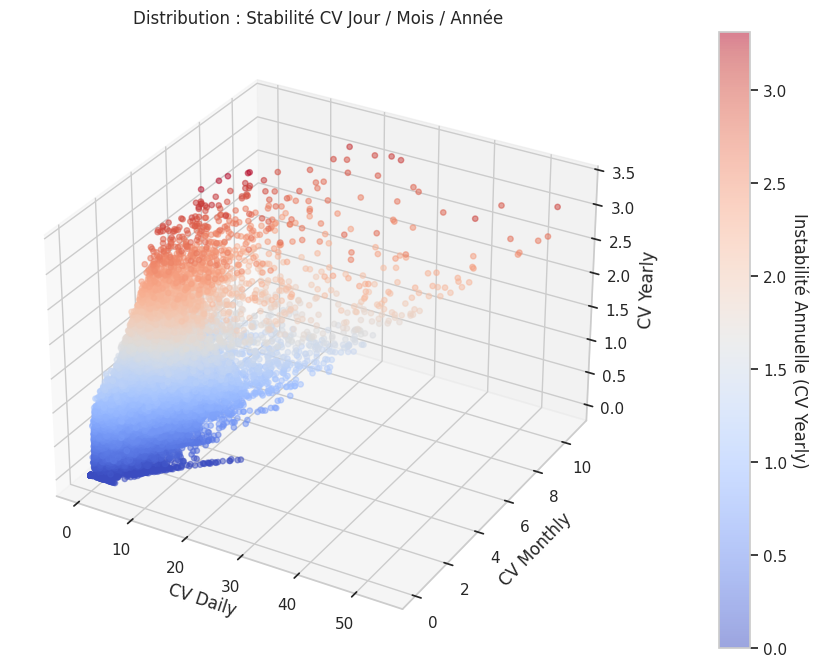

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# X=Daily, Y=Monthly, Z=Yearly. La couleur (c) dépend de Yearly pour bien voir l'anomalie annuelle.
scatter = ax.scatter(
    df_dispersion['cv_daily'], 
    df_dispersion['cv_monthly'], 
    df_dispersion['cv_yearly'],
    c=df_dispersion['cv_yearly'], 
    cmap='coolwarm', 
    alpha=0.5, 
    s=15
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Instabilité Annuelle (CV Yearly)', rotation=270, labelpad=15)

ax.set_xlabel('CV Daily')
ax.set_ylabel('CV Monthly')
ax.set_zlabel('CV Yearly')
ax.set_title("Distribution : Stabilité CV Jour / Mois / Année")

plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# 1. K-Means Clustering
X = df_dispersion[['cv_daily', 'cv_monthly', 'cv_yearly']].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
df_dispersion['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# 2. Préparation des statistiques par cluster
# On calcule tout en une seule fois pour éviter les erreurs de renommage
stats_clusters = df_dispersion.groupby('Cluster_KMeans').agg(
    Nb_Sources=('Nom_Source', 'count'),
    Total_Articles=('total_articles', 'sum'),
    cv_daily=('cv_daily', 'mean'),
    cv_monthly=('cv_monthly', 'mean'),
    cv_yearly=('cv_yearly', 'mean')
)

# Extraction des exemples (Top 20)
exemples = df_dispersion.sort_values('total_articles', ascending=False).groupby('Cluster_KMeans')['Nom_Source'].apply(
    lambda x: ', '.join(x.head(20))
).reset_index().rename(columns={'Nom_Source': 'Exemples_Principaux'})

# 3. Fusion finale
bilan_complet = stats_clusters.merge(exemples, on='Cluster_KMeans')

# Calcul des pourcentages
tot_sources, tot_articles = bilan_complet['Nb_Sources'].sum(), bilan_complet['Total_Articles'].sum()
bilan_complet['%_Sources'] = (bilan_complet['Nb_Sources'] / tot_sources) * 100
bilan_complet['%_Articles'] = (bilan_complet['Total_Articles'] / tot_articles) * 100

# 4. Affichage final propre
colonnes = [
    'Cluster_KMeans', '%_Sources', '%_Articles', 'Nb_Sources', 
    'Total_Articles', 'cv_daily', 'cv_monthly', 'cv_yearly', 'Exemples_Principaux'
]

print("Bilan du K-Means (Segments GDELT) :")
display(bilan_complet[colonnes].sort_values('%_Articles', ascending=False).style.format({
    'cv_daily': '{:.2f}', 'cv_monthly': '{:.2f}', 'cv_yearly': '{:.2f}',
    'Nb_Sources': '{:,.0f}', 'Total_Articles': '{:,.0f}',
    '%_Sources': '{:.2f} %', '%_Articles': '{:.2f} %'
}).background_gradient(subset=['%_Articles'], cmap='Blues') \
  .background_gradient(subset=['%_Sources'], cmap='Purples'))

OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 64 or lower


Bilan du K-Means (Segments GDELT) :


,Cluster_KMeans,%_Sources,%_Articles,Nb_Sources,Total_Articles,cv_daily,cv_monthly,cv_yearly,Exemples_Principaux
4,4,42.49 %,72.50 %,"30,052","1,034,970,471",1.86,0.68,0.48,"iheart.com, yahoo.com, zazoom.it, indiatimes.com, msn.com, haberler.com, finanznachrichten.de, sina.com.tw, eastmoney.com, cnfol.com, udn.com, dailymail.co.uk, globo.com, uol.com.br, baomoi.com, ifeng.com, business-standard.com, news.yam.md, xinhuanet.com, naslovi.net"
1,1,30.29 %,23.87 %,"21,427","340,826,510",2.69,1.26,1.00,"sina.com.cn, tribunnews.com, reuters.com, bjhmoh.cn, wafa.ps, tvguide.co.uk, fasopresse.net, biztoc.com, inewsgr.com, pikiran-rakyat.com, sohu.com, wickedlocal.com, english.wafa.ps, kaixian.tv, joker.com, ziarelive.ro, dailypolitical.com, menafn.com, lopinion.ma, philstar.com"
3,3,9.90 %,3.22 %,"7,002","45,910,081",5.46,2.57,1.68,"entornointeligente.com, gaeubote.de, asiaone.com, alarmeringen.nl, qq.com, tin247.com, usofarn.com, ap.org, 247.libero.it, agenzianova.com, arabianewspaper.com, contacto-latino.com, sondakika.com, oem.com.mx, modernreaders.com, blogspot.com, terra.com, theenterpriseleader.com, terra.com.mx, goskagit.com"
2,2,1.80 %,0.27 %,"1,276","3,872,071",18.14,4.75,1.64,"scotcampus.com, surenio.com.ar, kamuturk.net, viewngr.com, elcentinelacatolico.org, tenthamendmentcenter.com, nieuwsbank.nl, amazonaws.com, maine207.org, newstrackindia.com, radyokabayan.com, oldschool1051.com, peruenlinea.pe, tygodnikjutrzenka.com, caymanreporter.com, filkhbr.com, elyaomnews.com, pakasiatimes.com, singaporeinformer.com, nashfm923krst.com"
0,0,15.52 %,0.14 %,"10,974","2,029,785",7.13,1.73,0.79,"xornalgalicia.com, thebangladeshtoday.com, jhnews.com.cn, mmstd.com, afriquinfos.com, newbusinessethiopia.com, sixactualites.fr, dnkb.com.cn, iruya.com, thesierraleonetelegraph.com, shabait.com, vdi-nachrichten.com, blackholezoo.com, myitmakhamediagroup.com, femina.in, just-food.com, pop1.us, superbike-news.co.uk, elcontact.com, momentoverdadeiro.com"


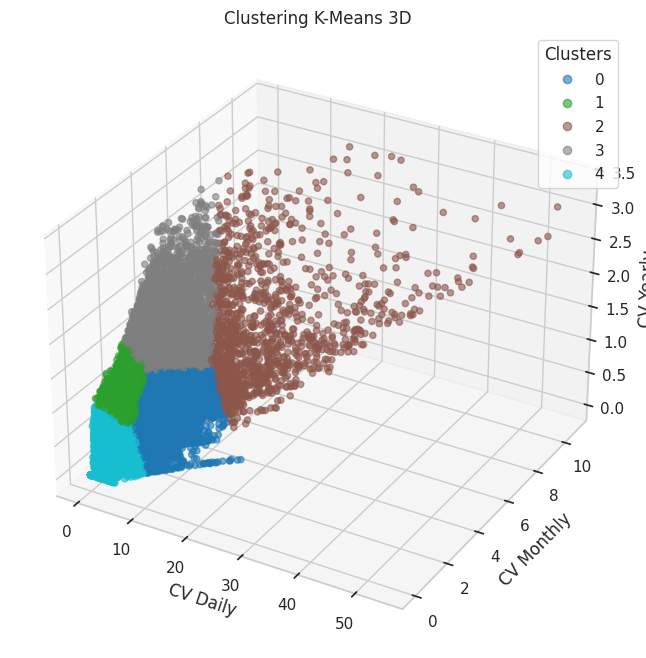

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_dispersion['cv_daily'], 
    df_dispersion['cv_monthly'], 
    df_dispersion['cv_yearly'],
    c=df_dispersion['Cluster_KMeans'], 
    cmap='tab10', 
    alpha=0.6
)

ax.set_xlabel('CV Daily')
ax.set_ylabel('CV Monthly')
ax.set_zlabel('CV Yearly')

plt.title("Clustering K-Means 3D")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [10]:
# On filtre pour ne garder que le cœur de l'information (Cluster 4 = Piliers, Cluster 1 = Quotidiens)
df_gold = df_dispersion[df_dispersion['Cluster_KMeans'].isin([1, 4])].copy()

# On crée aussi le complément (le "bruit" ou "zone d'étude secondaire")
df_noise = df_dispersion[~df_dispersion['Cluster_KMeans'].isin([1, 4])].copy()

print(f"✅ Vue 'Gold Standard' créée : {len(df_gold):,} sources conservées.")
print(f"⚠️ Médias exclus (Cluster 0, 2, 3) : {len(df_noise):,} sources écartées.")

✅ Vue 'Gold Standard' créée : 51,479 sources conservées.
⚠️ Médias exclus (Cluster 0, 2, 3) : 19,252 sources écartées.


In [13]:
# Lance ça juste avant ta requête SQL
print(con.execute("DESCRIBE daily_counts;").df())

  column_name column_type null   key default extra
0      Src_ID      BIGINT  YES  None    None  None
1      period        DATE  YES  None    None  None
2  n_articles      BIGINT  YES  None    None  None


In [16]:
df_gold.head()

,Nom_Source,total_articles,lifespan_days,lifespan_years,avg_daily,stddev_daily,cv_daily,avg_monthly,stddev_monthly,cv_monthly,avg_yearly,stddev_yearly,cv_yearly,Cluster_KMeans
4210,news33.tv,"1,816.00",923,4,1.97,5.67,2.88,58.58,155.14,2.65,454.00,387.19,0.85,1
4521,todayinbc.com,"2,294.00",630,3,3.64,11.42,3.14,104.27,269.96,2.59,764.67,721.74,0.94,1
4570,toplumhaber.com,"1,403.00",669,2,2.10,7.18,3.43,61.00,157.42,2.58,701.50,700.50,1.00,1
4776,formatonews.it,258.00,1205,5,0.21,0.72,3.35,6.29,15.99,2.54,51.60,54.94,1.06,1
4833,radiointereconomia.com,"10,441.00",646,2,16.16,44.73,2.77,474.59,"1,201.23",2.53,"5,220.50","5,205.50",1.00,1


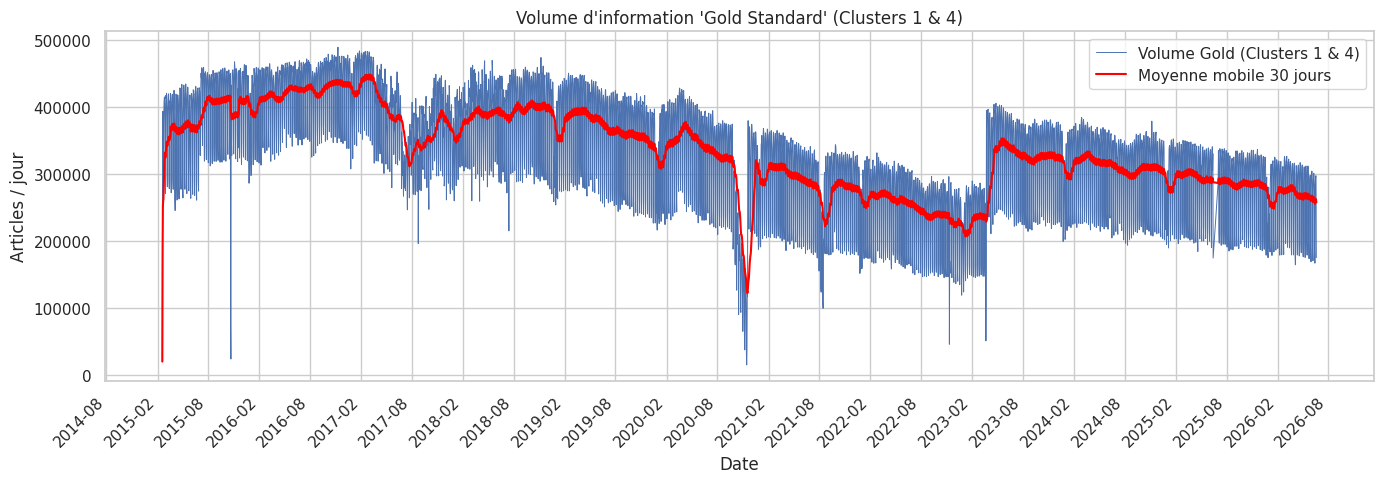

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. On crée une liste des Src_ID qui appartiennent à notre 'Gold Standard'
# 1. On récupère la liste des noms du gold standard
gold_names = list(df_gold['Nom_Source'].unique())

# 2. On utilise une jointure SQL pour faire correspondre les noms avec les ID numériques
# DuckDB gère le filtrage via la table 'src_map'
gold_daily_counts = con.execute(f"""
    SELECT 
        d.period, 
        SUM(d.n_articles) AS n_articles
    FROM daily_counts AS d
    INNER JOIN src_map AS m ON d.Src_ID = m.Src_ID
    WHERE m.SourceCommonName IN ({','.join([f"'{name}'" for name in gold_names])})
    GROUP BY d.period
    ORDER BY d.period ASC;
""").df()

# 3. Conversion du résultat en Timeseries (le reste de ton code ne bouge pas)
# 3. Conversion du résultat en Timeseries (UNE SEULE FOIS)
# Vérifions d'abord si 'period' est une colonne ou déjà l'index
if 'period' in gold_daily_counts.columns:
    gold_daily_counts['period'] = pd.to_datetime(gold_daily_counts['period'])
    gold_daily_counts.set_index('period', inplace=True)
elif not isinstance(gold_daily_counts.index, pd.DatetimeIndex):
    # Si 'period' est déjà l'index, on le convertit directement
    gold_daily_counts.index = pd.to_datetime(gold_daily_counts.index)

# Maintenant 'gold_daily_counts' est prêt pour le graphique

# 4. Graphique adapté
fig, ax = plt.subplots(figsize=(14, 5))

# Plot du volume réel
gold_daily_counts["n_articles"].plot(ax=ax, linewidth=0.7, label="Volume Gold (Clusters 1 & 4)")

# Moyenne mobile 30 jours
gold_daily_counts["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax, linewidth=1.5, color="red", label="Moyenne mobile 30 jours"
)

ax.set_title("Volume d'information 'Gold Standard' (Clusters 1 & 4)")
ax.set_ylabel("Articles / jour")
ax.set_xlabel("Date")

# Mise en forme des dates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

In [1]:
# 1. Calcul des nouvelles métriques par article
# On crée une table temporaire pour les métriques de contenu
con.execute("""
    CREATE OR REPLACE TABLE content_metrics AS
    SELECT 
        Src_ID,
        GKGRECORDID,
        WordCount AS length,
        -- Nombre de thèmes uniques (en supprimant les doublons dans EnhancedThemes)
        ARRAY_LENGTH(list_distinct(string_split(EnhancedThemes, ';'))) AS unique_themes
    FROM gkg_final
    WHERE WordCount IS NOT NULL;
""")

# 2. Calcul du CV pour chaque média sur ces nouvelles dimensions
df_content = con.execute("""
    WITH media_stats AS (
        SELECT 
            Src_ID,
            -- Moyennes
            AVG(length) AS avg_length,
            AVG(unique_themes) AS avg_themes,
            -- Variances (E(X^2) - E(X)^2)
            (AVG(length * length) - POW(AVG(length), 2)) AS var_length,
            (AVG(unique_themes * unique_themes) - POW(AVG(unique_themes), 2)) AS var_themes
        FROM content_metrics
        GROUP BY 1
    )
    SELECT 
        m.SourceCommonName AS Nom_Source,
        avg_length,
        CASE WHEN avg_length > 0 THEN SQRT(GREATEST(var_length, 0)) / avg_length ELSE 0 END AS cv_length,
        avg_themes,
        CASE WHEN avg_themes > 0 THEN SQRT(GREATEST(var_themes, 0)) / avg_themes ELSE 0 END AS cv_themes
    FROM media_stats s
    JOIN src_map m ON s.Src_ID = m.SourceCommonName_ID
    WHERE avg_length > 0;
""").df()

# 3. K-Means Clustering sur le Contenu
X_cont = df_content[['cv_length', 'cv_themes']].copy()
X_cont_scaled = StandardScaler().fit_transform(X_cont)
df_content['Cluster_Content'] = KMeans(n_clusters=4, random_state=42, n_init='auto').fit_predict(X_cont_scaled)

# 4. Affichage du résultat (2D car nous avons 2 variables de contenu)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_content.sample(5000), x='cv_length', y='cv_themes', 
                hue='Cluster_Content', palette='viridis', alpha=0.5)
plt.title("Clustering : Format éditorial (Longueur vs Diversité Thématique)")
plt.xlabel("Coefficient de Variation de la Longueur")
plt.ylabel("Coefficient de Variation des Thèmes")
plt.show()

# 5. Bilan des clusters de contenu
bilan_content = df_content.groupby('Cluster_Content').agg(
    Nb_Sources=('Nom_Source', 'count'),
    Avg_Length=('avg_length', 'mean'),
    Avg_Themes=('avg_themes', 'mean'),
    CV_Length=('cv_length', 'mean'),
    CV_Themes=('cv_themes', 'mean')
)
display(bilan_content.style.background_gradient(cmap='YlGnBu'))

NameError: name 'con' is not defined